In [1]:
import scanpy as sc

# 读取 .h5ad 文件
adata_all = sc.read("/public/users/xueyupeng/VZV/lvzhu/record/adata_all_celltype_50k.h5ad")

In [3]:
markers = ['CD8_112Cd','CD3_113In',  'CD4_115In', 'CD57_139La', 'CD56_141Pr', 
           'IgD_142Nd', 'IFN-a_144Nd', 'CXCL9_146Nd', 'CD86_147Sm','H3K27ac_148Nd', 
           'IL-1b_149Sm', '4E-BP1_150Nd', 'pS6_151Eu','CCR2_152Sm', 'TNF-a_153Eu', 
           'IL-4_154Sm', 'CD14_155Gd', 'CASP-8_156Gd','TCR-gd_158Gd', 'CD38_159Tb', 
           'CD27_160Gd', 'CD123_161Dy','Ki-67_162Dy', 'CXCL10_163Dy', 'Arginase-1_164Dy', 
           'IL-6_165Ho','MCP-1_166Er', 'CD69_167Er', 'STC1_168Er', 'GZMB_169Tm', 
           'CD45RA_170Er','HLA-DR_171Yb', 'IFN-g_172Yb', 'CD11c_173Yb', 'CD19_174Yb',
       'pSTAT1_175Lu', 'pSTAT3_176Yb',  'CD16_209Bi']

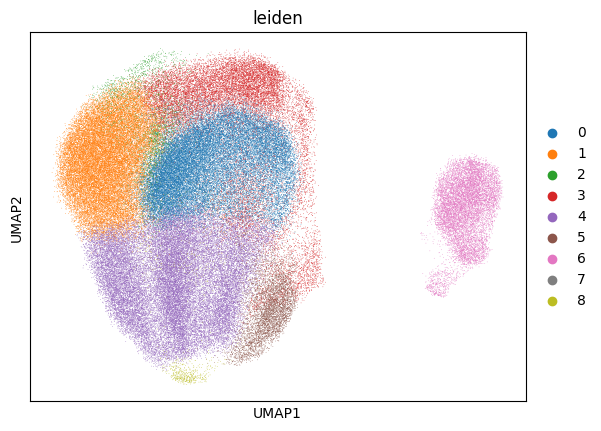

In [5]:
# Filter the AnnData object by specific celltypes  
# 按特定细胞类型过滤 AnnData 对象
celltypes_of_interest = ['DC']

adata_filtered = adata_all[adata_all.obs['celltype'].isin(celltypes_of_interest)].copy()

mask = adata_filtered.var_names.isin(markers)

# Perform PCA (if not already performed)
sc.tl.pca(adata_filtered, svd_solver='arpack', n_comps=30,mask_var=mask)

# Compute the neighborhood graph
sc.pp.neighbors(adata_filtered, n_neighbors=10, use_rep='X_pca')

# Perform UMAP (if not already performed)
sc.tl.umap(adata_filtered)

# Perform clustering (e.g., Leiden clustering)
sc.tl.leiden(
    adata_filtered,
    resolution=0.5,
    flavor="igraph",
    n_iterations=2,
    directed=False
)

# You can also visualize the UMAP with Leiden clustering results
sc.pl.umap(adata_filtered, color=['leiden'])

In [21]:
markers_dc = ['CD11c_173Yb', 'HLA-DR_171Yb', 'CD123_161Dy', 'CD86_147Sm', 'CD38_159Tb','CD16_209Bi','CD14_155Gd']

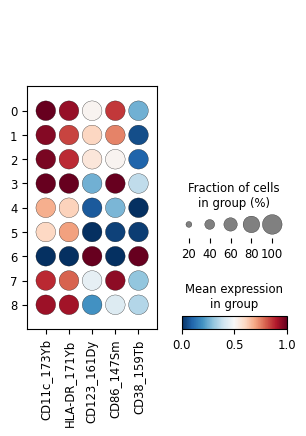

In [9]:
import matplotlib.pyplot as pl

dp = sc.pl.dotplot(
    adata_filtered,
    var_names=markers_dc,
    groupby="leiden",
    standard_scale="var",
    cmap="RdBu_r",
    return_fig=True
)
dp.savefig("/public/users/xueyupeng/VZV/lvzhu/figures/dotplot_markers_DC.png", dpi=300)

In [ ]:
sc.settings.figdir = "/public/users/xueyupeng/VZV/lvzhu/figures"
os.makedirs("/public/users/xueyupeng/VZV/lvzhu/figures", exist_ok=True)

In [ ]:
sc.pl.umap(
    adata_all,
    color="celltype",
    legend_loc="on data",
    frameon=False,
    size=0.1,
    title="UMAP - Celltype",
    save=f"_DC_subtype.png"
)

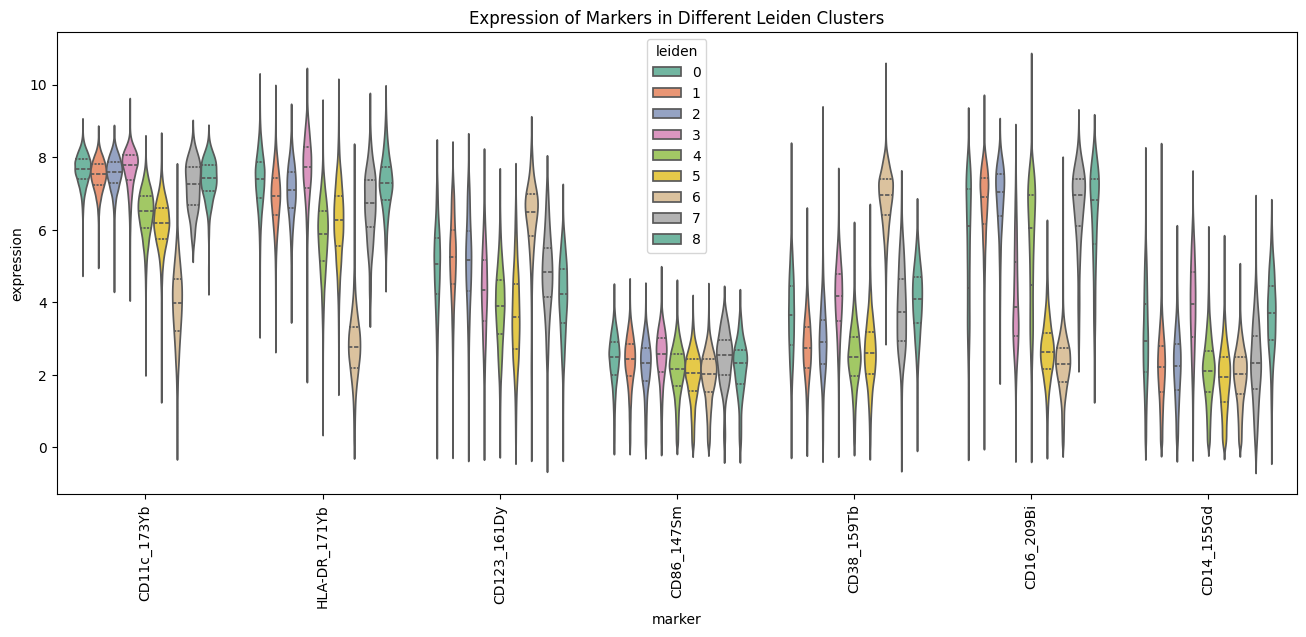

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 选择需要的小提琴图标记物
markers_DC = ['CD11c_173Yb', 'HLA-DR_171Yb', 'CD123_161Dy', 'CD86_147Sm', 'CD38_159Tb','CD16_209Bi','CD14_155Gd']

# 获取标记物的表达数据
data_long = adata_filtered.obs[['leiden']].copy()
for marker in markers_DC:
    data_long[marker] = adata_filtered[:, marker].X.toarray().flatten()  # 获取表达数据并转换为扁平化的数组

# 将数据转换为长格式
data_long = pd.melt(data_long, id_vars=['leiden'], value_vars=markers_DC,
                    var_name='marker', value_name='expression')

# 绘制小提琴图
plt.figure(figsize=(16, 6))
sns.violinplot(x='marker', y='expression', hue='leiden', data=data_long, split=False, inner="quart",
               palette="Set2", dodge=True)
plt.xticks(rotation=90)
plt.title("Expression of Markers in Different Leiden Clusters")
plt.show()

In [13]:
# 统计每个cluster的细胞数
cluster_counts = adata_filtered.obs['leiden'].value_counts()

# 显示结果
print(cluster_counts)

leiden
4    34125
0    29760
1    27678
3    17380
6    10341
5     5401
2     2751
8      703
7      242
Name: count, dtype: int64


In [14]:
import scanpy as sc
import pandas as pd

# 1. 计算差异表达基因（使用t-test，其他方法如 'wilcoxon' 或 'logreg' 可选）
sc.tl.rank_genes_groups(adata_filtered, groupby='leiden', groups=['0','1', '2','3','4','5','6','7','8'], method='t-test', corr_method='benjamini-hochberg')

In [ ]:
# 2. 获取结果并转换为DataFrame
result = adata_filtered.uns['rank_genes_groups']
gene_names = result['names']['0']  # '0'代表cluster0，'2'代表cluster2

# 获取对数变化（log fold change）、p值、校正后的p值等信息
logfoldchanges = result['logfoldchanges']['0']
pvals = result['pvals']['0']
pvals_adj = result['pvals_adj']['0']

# 创建DataFrame来展示差异表达基因及其对应的统计信息
marker_df = pd.DataFrame({
    'gene': gene_names,
    'logfoldchanges': logfoldchanges,
    'pvals': pvals,
    'pvals_adj': pvals_adj
})

# 3. 筛选显著差异表达基因（例如，p值小于0.05）
significant_markers = marker_df[marker_df['pvals_adj'] < 0.05]

# 4. 查看差异表达基因
print(significant_markers)

In [15]:
def get_differentially_expressed_genes(adata, cluster_name):
    """
    获取指定cluster的差异表达基因列表

    参数:
    - adata: AnnData 对象，包含所有数据
    - cluster_name: 要获取差异表达基因的 cluster 名称，例如 '0' 或 '2'

    返回:
    - pd.DataFrame: 包含显著差异表达基因及其统计信息的 DataFrame
    """
    # 获取差异表达分析的结果
    result = adata.uns['rank_genes_groups']
    
    # 获取指定 cluster 的基因信息
    gene_names = result['names'][cluster_name]
    logfoldchanges = result['logfoldchanges'][cluster_name]
    pvals = result['pvals'][cluster_name]
    pvals_adj = result['pvals_adj'][cluster_name]

    # 创建 DataFrame 来展示差异表达基因及其对应的统计信息
    marker_df = pd.DataFrame({
        'gene': gene_names,
        'logfoldchanges': logfoldchanges,
        'pvals': pvals,
        'pvals_adj': pvals_adj
    })

    # 筛选显著差异表达基因（例如，p值小于0.05）
    significant_markers = marker_df[marker_df['pvals_adj'] < 0.05]

    # 返回差异表达基因列表
    return significant_markers

In [17]:
get_differentially_expressed_genes(adata_filtered,'0')

,gene,logfoldchanges,pvals,pvals_adj
0,CD8_112Cd,2.830792,0.000000e+00,0.000000e+00
1,CD45-1_106Cd,4.417439,0.000000e+00,0.000000e+00
2,CD11c_173Yb,1.357501,0.000000e+00,0.000000e+00
3,pSTAT3_176Yb,1.390538,0.000000e+00,0.000000e+00
4,pSTAT1_175Lu,1.342927,0.000000e+00,0.000000e+00
5,HLA-DR_171Yb,1.701495,0.000000e+00,0.000000e+00
6,CASP-8_156Gd,0.805108,0.000000e+00,0.000000e+00
7,GZMB_169Tm,0.828089,0.000000e+00,0.000000e+00
8,MCP-1_166Er,1.060849,0.000000e+00,0.000000e+00
9,CSR,0.257679,0.000000e+00,0.000000e+00


In [18]:
get_differentially_expressed_genes(adata_filtered,'1')

,gene,logfoldchanges,pvals,pvals_adj
0,CD16_209Bi,2.550979,0.000000e+00,0.000000e+00
1,pSTAT3_176Yb,1.340748,0.000000e+00,0.000000e+00
2,CD45RA_170Er,1.191456,0.000000e+00,0.000000e+00
3,CASP-8_156Gd,0.724198,0.000000e+00,0.000000e+00
4,CD11c_173Yb,1.050375,0.000000e+00,0.000000e+00
5,pSTAT1_175Lu,0.979416,0.000000e+00,0.000000e+00
6,GZMB_169Tm,0.710098,0.000000e+00,0.000000e+00
7,Arginase-1_164Dy,0.728732,0.000000e+00,0.000000e+00
8,CD19_174Yb,0.815843,0.000000e+00,0.000000e+00
9,MCP-1_166Er,0.748548,0.000000e+00,0.000000e+00


In [19]:
get_differentially_expressed_genes(adata_filtered,'2')

,gene,logfoldchanges,pvals,pvals_adj
0,IL-4_154Sm,1.550255,0.000000e+00,0.000000e+00
1,Arginase-1_164Dy,1.772515,0.000000e+00,0.000000e+00
2,pSTAT1_175Lu,1.472036,0.000000e+00,0.000000e+00
3,CXCL10_163Dy,1.445000,0.000000e+00,0.000000e+00
4,CD16_209Bi,2.252575,0.000000e+00,0.000000e+00
5,pSTAT3_176Yb,1.258902,0.000000e+00,0.000000e+00
6,MCP-1_166Er,1.470198,0.000000e+00,0.000000e+00
7,CD11c_173Yb,0.915474,0.000000e+00,0.000000e+00
8,STC1_168Er,1.437295,0.000000e+00,0.000000e+00
9,CASP-8_156Gd,0.682603,0.000000e+00,0.000000e+00


In [23]:
cluster_anno = {
    "0": "cDC",
    "1": "cDC",
    "2": "cDC",
    "3": "cDC",
    "4": "cDC",
    "5": "cDC",
    "6": "pDC",
    "7": "cDC",
    "8": "cDC"
}
adata_filtered.obs["subtype"] = adata_filtered.obs["leiden"].map(cluster_anno)

In [32]:
cell_info_df = pd.DataFrame({
    'cellid': adata_filtered.obs.index,  # 细胞ID
    'sample': adata_filtered.obs['Sample'],  # 样本ID
    'celltype': adata_filtered.obs['celltype'],  # 细胞类型
    'subtype': adata_filtered.obs['subtype'] # 细胞亚型  
})
cell_info_df.head()
cell_info_df.to_csv('/public/users/xueyupeng/VZV/lvzhu/record/subtype_annotations_DC.csv', index=False)

In [24]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ========= 输出目录 =========
base_dir = "/public/users/xueyupeng/VZV/lvzhu/figures_subtype_DC/"
dir1 = os.path.join(base_dir, "1_threshold_distribution_DC")
dir2 = os.path.join(base_dir, "2_positive_ratio_DC")
dir3 = os.path.join(base_dir, "3_positive_median_DC")
dir4 = os.path.join(base_dir, "4_positive_geomean_DC")

for d in [dir1, dir2, dir3, dir4]:
    os.makedirs(d, exist_ok=True)

# ========= 参数 =========
sub_markers = ['IgD_142Nd', 'IFN-a_144Nd', 'CXCL9_146Nd', 'CD86_147Sm','H3K27ac_148Nd', 
               'IL-1b_149Sm', '4E-BP1_150Nd', 'pS6_151Eu','CCR2_152Sm', 'TNF-a_153Eu', 
               'IL-4_154Sm', 'CASP-8_156Gd','CD38_159Tb', 'CD123_161Dy','Ki-67_162Dy', 
               'CXCL10_163Dy', 'Arginase-1_164Dy', 'IL-6_165Ho','MCP-1_166Er', 
               'CD69_167Er', 'STC1_168Er', 'IFN-g_172Yb','pSTAT1_175Lu', 'pSTAT3_176Yb']


timepoints = sorted(adata_filtered.obs['Timepoint'].unique())
subtypes = sorted(adata_filtered.obs['subtype'].unique())

# ========= 1️⃣ 计算阈值 =========
v1day0_idx = (adata_filtered.obs['Timepoint'] == 'V1Day0')
marker_stats = {}

for ct in subtypes:
    ct_idx = v1day0_idx & (adata_filtered.obs['subtype'] == ct)
    for marker in sub_markers:
        if marker not in adata_filtered.var_names:
            continue
        idx_marker = adata_filtered.var_names.get_loc(marker)
        data_vec = adata_filtered[ct_idx, idx_marker].X
        data_vec = data_vec.toarray().flatten() if hasattr(data_vec, "toarray") else np.ravel(data_vec)

        median = np.median(data_vec)
        sd = np.std(data_vec)
        marker_stats[(ct, marker)] = median + 2*sd

# ========= 2️⃣ 统计 =========
records = []

for ct in subtypes:
    for marker in sub_markers:
        if (ct, marker) not in marker_stats:
            continue

        idx_marker = adata_filtered.var_names.get_loc(marker)
        threshold = marker_stats[(ct, marker)]

        for sample in adata_filtered.obs['Sample'].unique():
            for tp in timepoints:

                mask = (
                    (adata_filtered.obs['Sample'] == sample) &
                    (adata_filtered.obs['Timepoint'] == tp) &
                    (adata_filtered.obs['subtype'] == ct)
                )

                if mask.sum() == 0:
                    continue

                data_vec = adata_filtered[mask, idx_marker].X
                data_vec = data_vec.toarray().flatten() if hasattr(data_vec, "toarray") else np.ravel(data_vec)

                pos = data_vec[data_vec > threshold]

                pos_ratio = len(pos) / len(data_vec) * 100

                pos_median = np.median(pos) if len(pos) > 0 else np.nan

                # 几何平均数（避免0）
                pos_geomean = np.exp(np.mean(np.log(pos + 1e-9))) if len(pos) > 0 else np.nan

                records.append({
                    "Sample": sample,
                    "Timepoint": tp,
                    "subtype": ct,
                    "Marker": marker,
                    "Positive_Ratio_%": pos_ratio,
                    "Positive_Median": pos_median,
                    "Positive_Geomean": pos_geomean
                })

marker_summary = pd.DataFrame(records)

In [25]:
# ========= 保存路径 =========
save_dir = "/public/users/xueyupeng/VZV/lvzhu/figures_subtype_DC/"
os.makedirs(save_dir, exist_ok=True)

# ========= 1️⃣ 保存 marker_summary =========
marker_summary_path = os.path.join(save_dir, "marker_summary_subtype.csv")
marker_summary.to_csv(marker_summary_path, index=False)
print(f"✓ marker_summary 已保存: {marker_summary_path}")

# ========= 2️⃣ 保存阈值表 =========
# dict → DataFrame
threshold_df = pd.DataFrame([
    {
        "subtype": ct,
        "Marker": marker,
        "Threshold": thresh
    }
    for (ct, marker), thresh in marker_stats.items()
])

threshold_path = os.path.join(save_dir, "marker_thresholds_subtype.csv")
threshold_df.to_csv(threshold_path, index=False)
print(f"✓ 阈值表已保存: {threshold_path}")

# ========= 3️⃣ 基本信息检查 =========
print("\n=== 数据概览 ===")
print("marker_summary shape:", marker_summary.shape)
print("threshold_df shape:", threshold_df.shape)

print("\n=== marker_summary 前5行 ===")
print(marker_summary.head())

print("\n=== threshold_df 前5行 ===")
print(threshold_df.head())

✓ marker_summary 已保存: /public/users/xueyupeng/VZV/lvzhu/figures_subtype_DC/marker_summary_subtype.csv
✓ 阈值表已保存: /public/users/xueyupeng/VZV/lvzhu/figures_subtype_DC/marker_thresholds_subtype.csv

=== 数据概览 ===
marker_summary shape: (7488, 7)
threshold_df shape: (48, 3)

=== marker_summary 前5行 ===
    Sample Timepoint subtype     Marker  Positive_Ratio_%  Positive_Median  \
0  A004_V1    V1Day1     cDC  IgD_142Nd          0.585284         4.958301   
1  A007_V0    V1Day0     cDC  IgD_142Nd          2.022472         3.731646   
2  A016_V1    V1Day1     cDC  IgD_142Nd          0.416667         5.210746   
3  A007_V3    V2Day0     cDC  IgD_142Nd          1.305483         4.060730   
4  A005_V4    V2Day1     cDC  IgD_142Nd          0.000000              NaN   

   Positive_Geomean  
0          4.875914  
1          4.318188  
2          5.210746  
3          4.145110  
4               NaN  

=== threshold_df 前5行 ===
  subtype         Marker  Threshold
0     cDC      IgD_142Nd   3.676305
1   

In [26]:
# ========= 图1：阈值分布（按 subtype） =========
for ct in subtypes:
    for marker in sub_markers:

        if marker not in adata_filtered.var_names:
            continue
        if (ct, marker) not in marker_stats:
            continue

        idx_marker = adata_filtered.var_names.get_loc(marker)
        threshold = marker_stats[(ct, marker)]

        plt.figure(figsize=(6,5))

        # 每个 sample 一条曲线
        for sample in adata_filtered.obs['Sample'].unique():
            mask = (
                (adata_filtered.obs['Sample'] == sample) &
                (adata_filtered.obs['subtype'] == ct)
            )

            if mask.sum() == 0:
                continue

            data_vec = adata_filtered[mask, idx_marker].X
            data_vec = data_vec.toarray().flatten() if hasattr(data_vec, "toarray") else np.ravel(data_vec)

            # 防止全0或常数导致kde报错
            if np.std(data_vec) == 0:
                continue

            sns.kdeplot(data_vec, alpha=0.3)

        # 🔴 阈值线
        plt.axvline(threshold, color='red', linestyle='--', linewidth=2)

        plt.title(f"{marker} ({ct})")
        plt.xlabel("Expression")
        plt.ylabel("Density")

        plt.legend([],[],frameon=False)
        plt.tight_layout()

        plt.savefig(f"{dir1}/{marker}_{ct}_distribution.png", dpi=300)
        plt.close()

In [27]:
def plot_box_scatter(df, y, ylabel, save_dir, marker, ct):

    # ❗ 固定时间顺序
    timepoint_order = ["V1Day0", "V1Day1", "V2Day0", "V2Day1"]

    # ❗ 去掉 NaN
    df = df.dropna(subset=[y])

    # ❗ 只保留定义顺序中的时间点
    df = df[df["Timepoint"].isin(timepoint_order)]

    # ❗ 每个 timepoint 至少2个点
    valid_counts = df.groupby("Timepoint")[y].count()
    if (valid_counts < 2).any():
        return

    # ❗ log轴不能有0或负值
    df = df[df[y] > 0]
    if df.shape[0] < 3:
        return

    plt.figure(figsize=(6,5))

    # ✅ 箱线图
    sns.boxplot(
        data=df,
        x="Timepoint",
        y=y,
        order=timepoint_order,   # ⭐ 固定顺序
        color="lightgray",
        showfliers=False
    )

    # ✅ 散点
    sns.stripplot(
        data=df,
        x="Timepoint",
        y=y,
        order=timepoint_order,
        hue="Sample",
        dodge=False,
        size=5,
        alpha=0.8,
        jitter=True
    )

    # ✅ log 轴
    plt.yscale("log")

    plt.ylabel(ylabel + " (log scale)")
    plt.xlabel("Timepoint")
    plt.title(f"{marker} ({ct})")

    # 去掉图例
    plt.legend([], [], frameon=False)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/{marker}_{ct}.png", dpi=300)
    plt.close()

In [28]:
for ct in subtypes:
    for marker in sub_markers:

        df = marker_summary[
            (marker_summary["Marker"] == marker) &
            (marker_summary["subtype"] == ct)
        ]

        if df.empty:
            continue

        # 图2：阳性比例
        plot_box_scatter(df, "Positive_Ratio_%", "Positive Ratio (%)", dir2, marker, ct)

        # 图3：阳性中位数
        plot_box_scatter(df, "Positive_Median", "Median Expression", dir3, marker, ct)

        # 图4：几何平均数
        plot_box_scatter(df, "Positive_Geomean", "Geometric Mean", dir4, marker, ct)

print("✅ 全部图片已保存")

✅ 全部图片已保存


In [29]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import os
import re

# ========= 从 Sample 提取 ID =========
def extract_id(sample):
    # A004_V3 -> A004
    return re.sub(r"_V\d+$", "", sample)

# 添加 ID 列
marker_summary["ID"] = marker_summary["Sample"].apply(extract_id)

# ========= 参数 =========
timepoint_pairs = [
    ("V1Day0", "V1Day1"),
    ("V2Day0", "V2Day1")
]

alpha = 0.05
results = []

# ========= 主循环 =========
subtypes = marker_summary["subtype"].dropna().unique()
markers = marker_summary["Marker"].dropna().unique()

for ct in subtypes:
    for marker in markers:

        df = marker_summary[
            (marker_summary["subtype"] == ct) &
            (marker_summary["Marker"] == marker)
        ]

        if df.empty:
            continue

        for tp1, tp2 in timepoint_pairs:

            df1 = df[df["Timepoint"] == tp1]
            df2 = df[df["Timepoint"] == tp2]

            if df1.empty or df2.empty:
                continue

            # ========= 用 ID 配对 =========
            common_IDs = set(df1["ID"]).intersection(set(df2["ID"]))

            if len(common_IDs) < 3:
                continue

            df1_id = df1[df1["ID"].isin(common_IDs)].set_index("ID")
            df2_id = df2[df2["ID"].isin(common_IDs)].set_index("ID")

            df1_id = df1_id.sort_index()
            df2_id = df2_id.sort_index()

            for metric in ["Positive_Ratio_%", "Positive_Median", "Positive_Geomean"]:

                if metric not in df.columns:
                    continue

                x = df1_id[metric]
                y = df2_id[metric]

                common = x.index.intersection(y.index)

                if len(common) < 3:
                    continue

                x = x.loc[common].dropna()
                y = y.loc[common].dropna()

                # 再次对齐
                common = x.index.intersection(y.index)
                x = x.loc[common]
                y = y.loc[common]

                if len(x) < 3:
                    continue

                # 跳过无变化
                if np.all(x == y):
                    continue

                # 跳过常数
                if x.nunique() < 2 or y.nunique() < 2:
                    continue

                try:
                    stat, p = wilcoxon(x, y)
                except Exception:
                    continue

                results.append({
                    "subtype": ct,
                    "Marker": marker,
                    "Comparison": f"{tp1} vs {tp2}",
                    "Metric": metric,
                    "N": len(common),
                    "Mean_1": x.mean(),
                    "Mean_2": y.mean(),
                    "Median_1": x.median(),
                    "Median_2": y.median(),
                    "p_value": p
                })

# ========= 转 DataFrame =========
results_df = pd.DataFrame(results)

print(f"Total valid tests: {len(results_df)}")

# ========= FDR 校正 =========
if not results_df.empty and "p_value" in results_df.columns:
    results_df["p_adj"] = multipletests(results_df["p_value"], method="fdr_bh")[1]
    results_df = results_df.sort_values("p_adj")
    results_sig = results_df[results_df["p_adj"] < alpha]
else:
    print("⚠️ 没有任何统计结果（请检查数据）")
    results_df["p_adj"] = []
    results_sig = results_df.copy()


Total valid tests: 191


In [30]:
# ========= 保存 =========
save_path = "/public/users/xueyupeng/VZV/lvzhu/figures_subtype_DC/significant_markers_with_FDR.xlsx"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

with pd.ExcelWriter(save_path) as writer:
    results_df.to_excel(writer, sheet_name="all_results", index=False)
    results_sig.to_excel(writer, sheet_name="significant_only", index=False)

print(f"✓ 保存完成: {save_path}")
print(f"✓ 总结果数: {len(results_df)}")
print(f"✓ 显著结果数 (FDR < {alpha}): {len(results_sig)}")

✓ 保存完成: /public/users/xueyupeng/VZV/lvzhu/figures_subtype_DC/significant_markers_with_FDR.xlsx
✓ 总结果数: 191
✓ 显著结果数 (FDR < 0.05): 0
